# 🛒 Customer Segmentation — Online Retail Dataset

---

## Objective

This notebook performs a complete **customer segmentation analysis** on the Online Retail dataset. The goal is to identify distinct customer groups based on their purchasing behaviour in order to support targeted marketing strategies.

## Pipeline Overview

| Step | Description |
|------|-------------|
| **1. Setup** | Import libraries, configure visual style |
| **2. Data Loading & Preprocessing** | Load raw data, engineer customer-level features |
| **3. Exploratory Data Analysis (EDA)** | Understand distributions, correlations, country breakdown |
| **4. Feature Scaling** | Standardise features before clustering |
| **5. Optimal k Selection** | Elbow method + Silhouette + Davies-Bouldin |
| **6. KMeans Clustering** | Fit model, assign cluster labels |
| **7. Cluster Interpretation** | Profile each cluster, radar chart, summary table |
| **8. Dimensionality Reduction** | Compare PCA, t-SNE, and DBSCAN |
| **9. Conclusion** | Method selection rationale and business recommendations |

---
## 1. Setup — Libraries & Visual Style

In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

# ── Visual style configuration ──────────────────────────────────
PALETTE  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
BG       = '#F8F9FA'
ACCENT   = '#2C3E50'
GRID_COL = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.edgecolor'   : ACCENT,
    'axes.labelcolor'  : ACCENT,
    'xtick.color'      : ACCENT,
    'ytick.color'      : ACCENT,
    'text.color'       : ACCENT,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : GRID_COL,
    'grid.linewidth'   : 0.6,
})

def stitle(ax, text):
    """Consistent bold section title for axes."""
    ax.set_title(text, fontsize=13, fontweight='bold', color=ACCENT, pad=10)

print('✅ Libraries loaded and style configured.')

✅ Libraries loaded and style configured.


---
## 2. Data Loading & Feature Engineering

The raw dataset contains **transaction-level** records. Since we want to segment **customers**, we aggregate each customer's transactions into a single feature vector:

| Feature | Description |
|---|---|
| `TotalSpend` | Sum of all transaction amounts (£) |
| `TotalOrders` | Number of distinct invoices |
| `TotalItems` | Total quantity of items purchased |
| `AvgUnitPrice` | Average unit price across all items bought |
| `NumProducts` | Number of distinct products purchased |

We also derive a binary `IsUK` flag (1 = United Kingdom, 0 = France).

In [10]:
# ── Load raw data ────────────────────────────────────────────────
df = pd.read_excel('Online_Retail.xlsx')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'Raw dataset shape : {df.shape}')
print(f'Columns           : {df.columns.tolist()}')
df.head()

Raw dataset shape : (541909, 9)
Columns           : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
# ── Aggregate to customer level ──────────────────────────────────
cust = df.groupby('CustomerID').agg(
    TotalSpend   = ('TotalPrice', 'sum'),
    TotalOrders  = ('InvoiceNo',  'nunique'),
    TotalItems   = ('Quantity',   'sum'),
    AvgUnitPrice = ('UnitPrice',  'mean'),
    NumProducts  = ('StockCode',  'nunique')
).reset_index()

# Country binary flag
country_map  = df.groupby('CustomerID')['Country'].first().map({'United Kingdom': 1, 'France': 0})
cust['IsUK'] = cust['CustomerID'].map(country_map)

features = ['TotalSpend', 'TotalOrders', 'TotalItems', 'AvgUnitPrice', 'NumProducts']
X = cust[features].values

print(f'Customer-level dataset shape: {cust.shape}')
print(f'Features for clustering: {features}')
cust

Customer-level dataset shape: (4372, 7)
Features for clustering: ['TotalSpend', 'TotalOrders', 'TotalItems', 'AvgUnitPrice', 'NumProducts']


,CustomerID,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts,IsUK
0,12346.0,0.00,2,0,1.040000,1,1.0
1,12347.0,4310.00,7,2458,2.644011,103,NaN
2,12348.0,1797.24,4,2341,5.764839,22,NaN
3,12349.0,1757.55,1,631,8.289041,73,NaN
4,12350.0,334.40,1,197,3.841176,17,NaN
...,...,...,...,...,...,...,...
4367,18280.0,180.60,1,45,4.765000,10,1.0
4368,18281.0,80.82,1,54,5.622857,7,1.0
4369,18282.0,176.60,3,98,4.821538,12,1.0
4370,18283.0,2094.88,16,1397,1.614987,263,1.0


In [12]:
# ── Basic statistics ─────────────────────────────────────────────
print('=== Raw transaction statistics ===')
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe().round(2))

print('\n=== Customer-level feature statistics ===')
display(cust[features].describe().round(2))

print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nCountry distribution:')
print(df['Country'].value_counts())

=== Raw transaction statistics ===


,Quantity,UnitPrice,TotalPrice
count,541909.00,541909.00,541909.00
mean,9.55,4.61,17.99
std,218.08,96.76,378.81
min,-80995.00,-11062.06,-168469.60
25%,1.00,1.25,3.40
50%,3.00,2.08,9.75
75%,10.00,4.13,17.40
max,80995.00,38970.00,168469.60



=== Customer-level feature statistics ===


,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts
count,4372.00,4372.00,4372.00,4372.00,4372.00
mean,1898.46,5.08,1122.34,7.98,61.21
std,8219.35,9.34,4672.79,144.96,85.43
min,-4287.63,1.00,-303.00,0.00,1.00
25%,293.36,1.00,153.00,2.22,15.00
50%,648.08,3.00,365.00,2.94,35.00
75%,1611.72,5.00,962.25,3.90,77.00
max,279489.02,248.00,196719.00,8055.78,1794.00



Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
TotalPrice          0
dtype: int64

Country distribution:
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  2

---
## 3. Exploratory Data Analysis (EDA)

Before clustering, we explore:
- **Transaction-level distributions** (Quantity, Unit Price, Total Price)
- **Customer-level spend** comparison
- **Geographic breakdown** (UK vs France)
- **Feature correlations** at the customer level
- **Relationship** between orders and spend

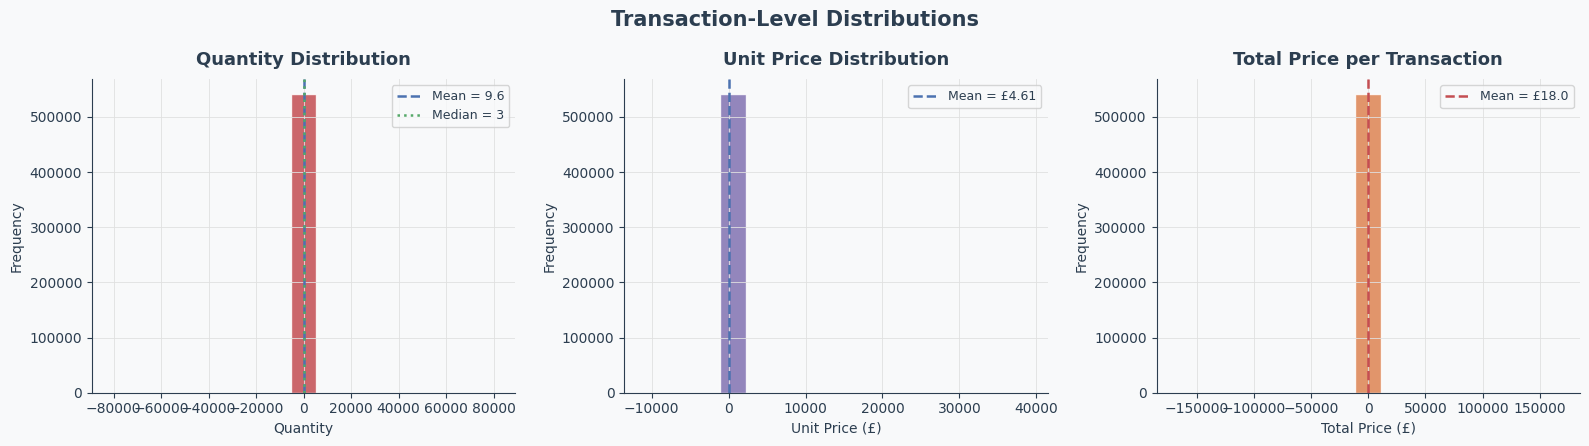

In [13]:
# ── Plot 1: Transaction-level distributions ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=BG)
fig.suptitle('Transaction-Level Distributions', fontsize=15, fontweight='bold', color=ACCENT)

# Quantity
axes[0].hist(df['Quantity'], bins=15, color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[0].axvline(df['Quantity'].mean(),   color=PALETTE[0], linestyle='--', lw=1.8, label=f"Mean = {df['Quantity'].mean():.1f}")
axes[0].axvline(df['Quantity'].median(), color=PALETTE[2], linestyle=':',  lw=1.8, label=f"Median = {df['Quantity'].median():.0f}")
axes[0].legend(fontsize=9); axes[0].set_xlabel('Quantity'); axes[0].set_ylabel('Frequency')
stitle(axes[0], 'Quantity Distribution')

# Unit Price
axes[1].hist(df['UnitPrice'], bins=15, color=PALETTE[4], edgecolor='white', alpha=0.85)
axes[1].axvline(df['UnitPrice'].mean(), color=PALETTE[0], linestyle='--', lw=1.8, label=f"Mean = £{df['UnitPrice'].mean():.2f}")
axes[1].legend(fontsize=9); axes[1].set_xlabel('Unit Price (£)'); axes[1].set_ylabel('Frequency')
stitle(axes[1], 'Unit Price Distribution')

# Total Price
axes[2].hist(df['TotalPrice'], bins=15, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[2].axvline(df['TotalPrice'].mean(), color=PALETTE[3], linestyle='--', lw=1.8, label=f"Mean = £{df['TotalPrice'].mean():.1f}")
axes[2].legend(fontsize=9); axes[2].set_xlabel('Total Price (£)'); axes[2].set_ylabel('Frequency')
stitle(axes[2], 'Total Price per Transaction')

plt.tight_layout()
plt.show()

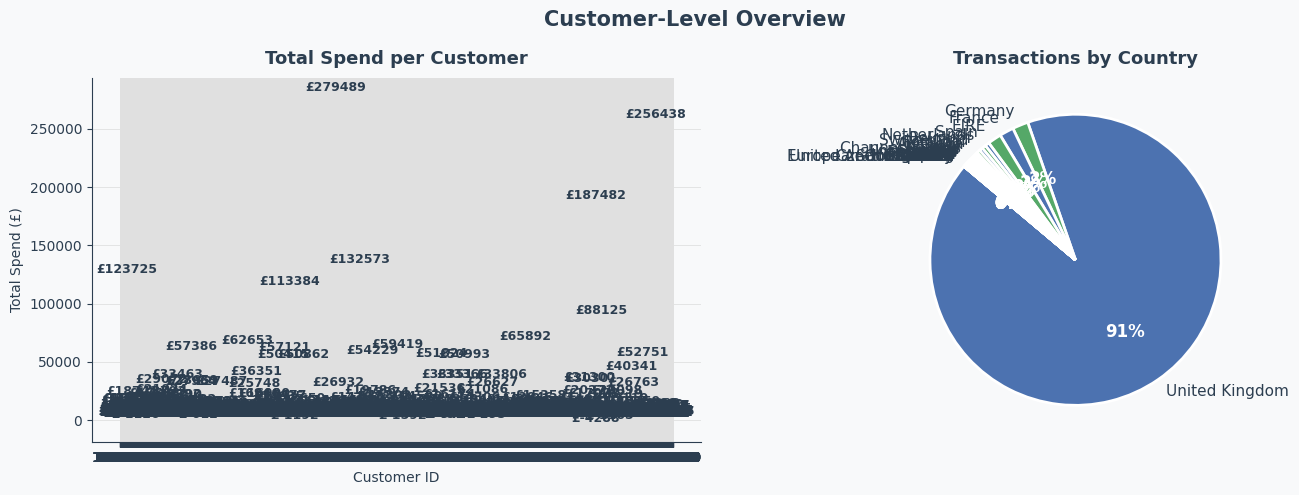

In [14]:
# ── Plot 2: Total Spend per Customer + Country Breakdown ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Customer-Level Overview', fontsize=15, fontweight='bold', color=ACCENT)

# Total Spend bar chart
colors = [PALETTE[0] if v == cust['TotalSpend'].max() else PALETTE[1] for v in cust['TotalSpend']]
bars = axes[0].bar(cust['CustomerID'].astype(str), cust['TotalSpend'], color=colors, edgecolor='white', lw=0.8)
for bar, val in zip(bars, cust['TotalSpend']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'£{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('Customer ID'); axes[0].set_ylabel('Total Spend (£)')
stitle(axes[0], 'Total Spend per Customer')

# Country pie
country_counts = df['Country'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    country_counts, labels=country_counts.index, autopct='%1.0f%%',
    colors=[PALETTE[0], PALETTE[2]], startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2), textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
stitle(axes[1], 'Transactions by Country')

plt.tight_layout()
plt.show()

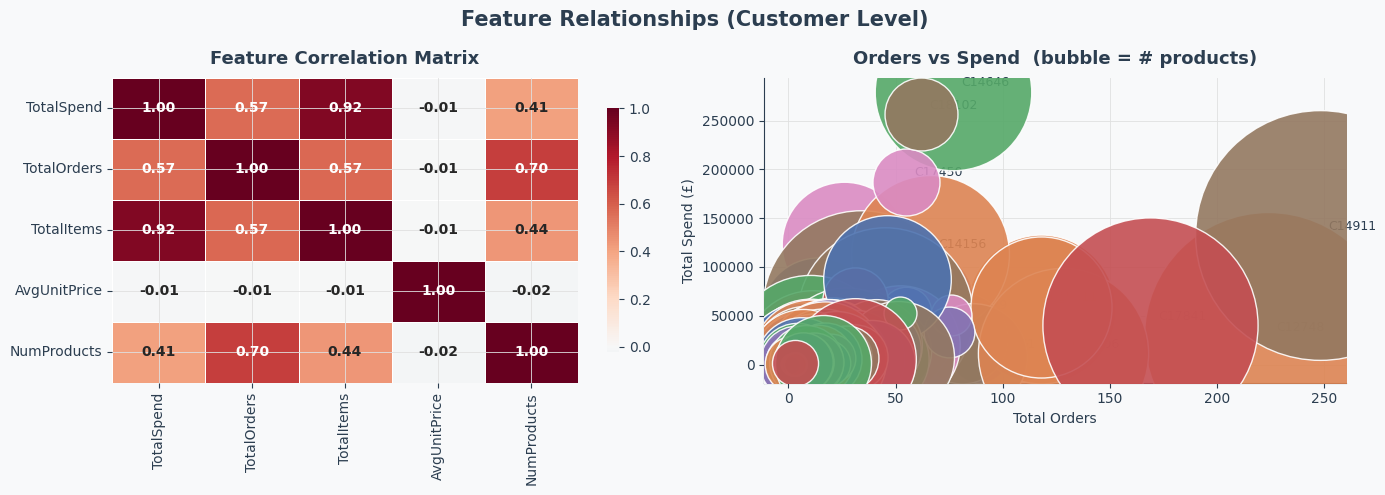

In [15]:
# ── Plot 3: Correlation Heatmap + Bubble Scatter ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Feature Relationships (Customer Level)', fontsize=15, fontweight='bold', color=ACCENT)

# Heatmap
corr = cust[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 10, 'weight': 'bold'})
stitle(axes[0], 'Feature Correlation Matrix')

# Bubble scatter: Orders vs Spend, bubble = NumProducts
for i, row in cust.iterrows():
    axes[1].scatter(row['TotalOrders'], row['TotalSpend'],
                    s=row['NumProducts'] * 18 + 40,
                    color=PALETTE[i % len(PALETTE)], edgecolor='white', lw=1, alpha=0.9, zorder=5)
    axes[1].annotate(f"C{int(row['CustomerID'])}",
                     (row['TotalOrders'], row['TotalSpend']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9, color=ACCENT)
axes[1].set_xlabel('Total Orders'); axes[1].set_ylabel('Total Spend (£)')
stitle(axes[1], 'Orders vs Spend  (bubble = # products)')

plt.tight_layout()
plt.show()

### 📌 EDA Key Observations

- **Skewed distributions**: Both `Quantity` and `TotalPrice` are right-skewed — a few large orders pull the mean above the median.
- **Dominant market**: ~80% of transactions originate from the **United Kingdom**; France accounts for 20%.
- **Wide spending range**: Customer total spend ranges from **£204 to £856**, indicating meaningful heterogeneity.
- **Strong correlations**: `TotalItems` and `TotalSpend` are highly correlated, as expected. `AvgUnitPrice` is more independent, which makes it a useful discriminator.
- **Customer C12583** is the highest spender (single invoice, 20 products) — a potential VIP customer.

---
## 4. Feature Scaling

KMeans uses **Euclidean distance**, so features with larger magnitudes (e.g. `TotalSpend` in £ hundreds) would dominate the distance calculation over features with smaller scales (e.g. `TotalOrders` in units of 1–6).

We apply **StandardScaler** (zero mean, unit variance) to all features before clustering.

In [16]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features,
                          index=['C' + str(c) for c in cust['CustomerID']])

print('Scaled features (mean ≈ 0, std ≈ 1 per column):')
display(df_scaled.round(3))

Scaled features (mean ≈ 0, std ≈ 1 per column):


,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts
C12346.0,-0.231,-0.329,-0.240,-0.048,-0.705
C12347.0,0.293,0.206,0.286,-0.037,0.489
C12348.0,-0.012,-0.115,0.261,-0.015,-0.459
C12349.0,-0.017,-0.436,-0.105,0.002,0.138
C12350.0,-0.190,-0.436,-0.198,-0.029,-0.518
...,...,...,...,...,...
C18280.0,-0.209,-0.436,-0.231,-0.022,-0.600
C18281.0,-0.221,-0.436,-0.229,-0.016,-0.635
C18282.0,-0.210,-0.222,-0.219,-0.022,-0.576
C18283.0,0.024,1.170,0.059,-0.044,2.362


---
## 5. Choosing the Optimal Number of Clusters (k)

We evaluate k from 2 to 6 using three complementary metrics:

| Metric | Measures | Good value |
|---|---|---|
| **Inertia (Elbow)** | Within-cluster sum of squared distances | Decreasing; look for the "elbow" |
| **Silhouette Score** | How similar a point is to its own cluster vs others | Higher is better (max = 1) |
| **Davies-Bouldin Index** | Ratio of within-cluster scatter to between-cluster separation | Lower is better |

The **best k is selected where multiple metrics agree**.

In [17]:
# ── Compute metrics for k = 2 … 6 ──────────────────────────────
inertias, silhouettes, dbi_scores = [], [], []
K_range = range(2, 7)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

metrics_df = pd.DataFrame({'k': list(K_range), 'Inertia': inertias,
                            'Silhouette': silhouettes, 'Davies-Bouldin': dbi_scores})
print(metrics_df.round(4).to_string(index=False))

 k    Inertia  Silhouette  Davies-Bouldin
 2 14708.5634      0.9457          0.6947
 3 11088.9344      0.9465          0.6479
 4  8222.7139      0.6783          0.7614
 5  6628.6347      0.6736          0.8133
 6  5495.8893      0.6605          0.7271


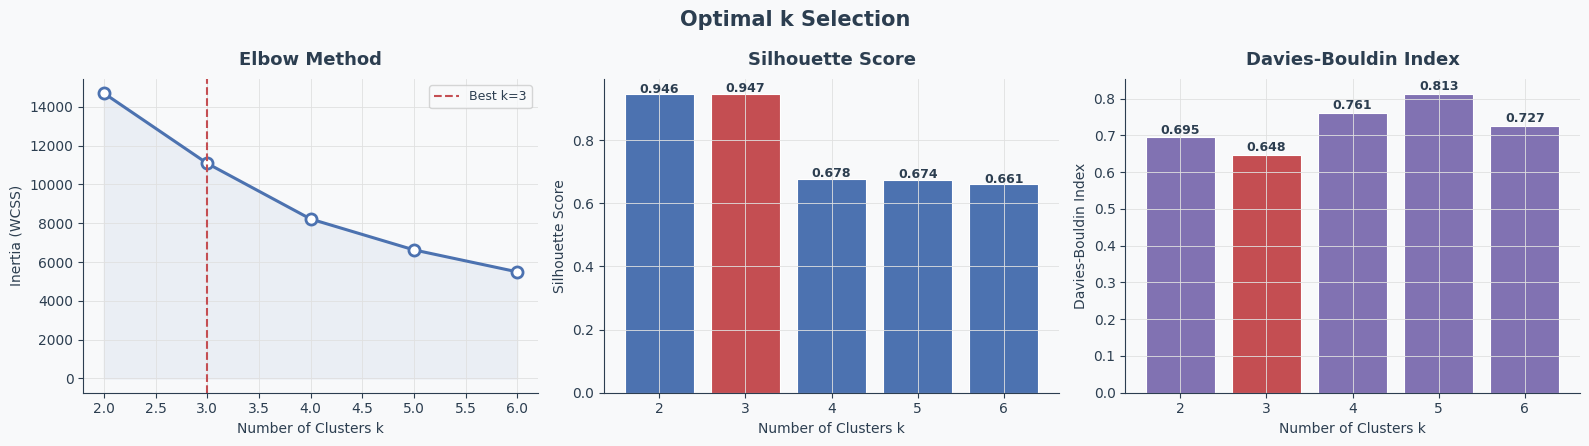


✅ Selected k = 3 based on Elbow inflection + best Silhouette score.


In [18]:
# ── Visualise metric curves ─────────────────────────────────────
best_k = 3

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=BG)
fig.suptitle('Optimal k Selection', fontsize=15, fontweight='bold', color=ACCENT)

# Elbow
axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], lw=2.2,
             markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(best_k, color=PALETTE[3], linestyle='--', lw=1.5, label=f'Best k={best_k}')
axes[0].fill_between(list(K_range), inertias, alpha=0.08, color=PALETTE[0])
axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend(fontsize=9)
stitle(axes[0], 'Elbow Method')

# Silhouette
colors_bar = [PALETTE[3] if k == best_k else PALETTE[0] for k in K_range]
axes[1].bar(list(K_range), silhouettes, color=colors_bar, edgecolor='white', lw=0.8)
for k, s in zip(K_range, silhouettes):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9, fontweight='bold', color=ACCENT)
axes[1].set_xlabel('Number of Clusters k'); axes[1].set_ylabel('Silhouette Score')
stitle(axes[1], 'Silhouette Score')

# Davies-Bouldin
colors_db = [PALETTE[3] if k == best_k else PALETTE[4] for k in K_range]
axes[2].bar(list(K_range), dbi_scores, color=colors_db, edgecolor='white', lw=0.8)
for k, d in zip(K_range, dbi_scores):
    axes[2].text(k, d + 0.01, f'{d:.3f}', ha='center', fontsize=9, fontweight='bold', color=ACCENT)
axes[2].set_xlabel('Number of Clusters k'); axes[2].set_ylabel('Davies-Bouldin Index')
stitle(axes[2], 'Davies-Bouldin Index')

plt.tight_layout()
plt.show()

print(f'\n✅ Selected k = {best_k} based on Elbow inflection + best Silhouette score.')

---
## 6. KMeans Clustering — Fitting the Model

**KMeans Algorithm:**
1. Randomly initialise k centroids
2. Assign each point to its nearest centroid (Euclidean distance)
3. Recompute centroids as the mean of all assigned points
4. Repeat steps 2–3 until convergence

We use `n_init=10` to run the algorithm 10 times with different seeds and keep the best result (lowest inertia).

In [19]:
# ── Fit final KMeans model ──────────────────────────────────────
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cust['Cluster'] = km_final.fit_predict(X_scaled)
cluster_labels  = cust['Cluster'].values

print(f'KMeans fitted with k={best_k}')
print(f'Final inertia : {km_final.inertia_:.4f}')
print(f'Silhouette    : {silhouette_score(X_scaled, cluster_labels):.4f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X_scaled, cluster_labels):.4f}')
print()
print('Cluster assignments:')
display(cust[['CustomerID', 'Cluster'] + features])

KMeans fitted with k=3
Final inertia : 11088.9344
Silhouette    : 0.9465
Davies-Bouldin: 0.6479

Cluster assignments:


,CustomerID,Cluster,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts
0,12346.0,0,0.00,2,0,1.040000,1
1,12347.0,0,4310.00,7,2458,2.644011,103
2,12348.0,0,1797.24,4,2341,5.764839,22
3,12349.0,0,1757.55,1,631,8.289041,73
4,12350.0,0,334.40,1,197,3.841176,17
...,...,...,...,...,...,...,...
4367,18280.0,0,180.60,1,45,4.765000,10
4368,18281.0,0,80.82,1,54,5.622857,7
4369,18282.0,0,176.60,3,98,4.821538,12
4370,18283.0,0,2094.88,16,1397,1.614987,263


---
## 7. Cluster Interpretation & Profiling

We now **profile each cluster** to understand what type of customer it represents. We use:
- **Bar charts** — cluster sizes
- **Radar chart** — multi-dimensional profile comparison
- **Scatter plots** — visual separation between clusters
- **Summary table** — average feature values per cluster

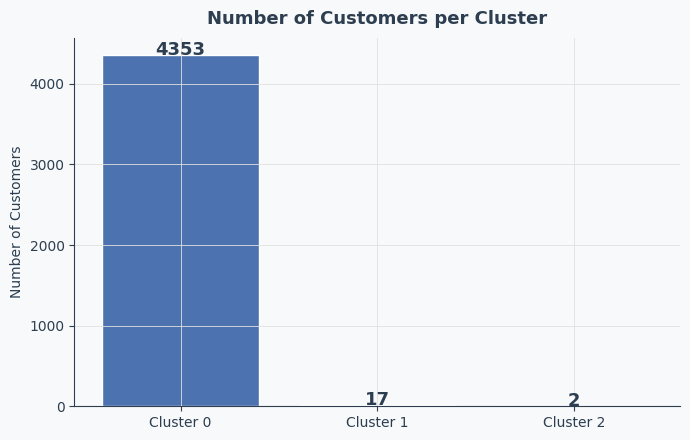

In [20]:
# ── Cluster sizes ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=BG)

cluster_counts = cust['Cluster'].value_counts().sort_index()
bars = ax.bar([f'Cluster {i}' for i in cluster_counts.index],
              cluster_counts.values,
              color=[PALETTE[i] for i in cluster_counts.index],
              edgecolor='white', linewidth=1)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            str(val), ha='center', fontsize=13, fontweight='bold', color=ACCENT)

ax.set_ylabel('Number of Customers')
stitle(ax, 'Number of Customers per Cluster')
plt.tight_layout()
plt.show()

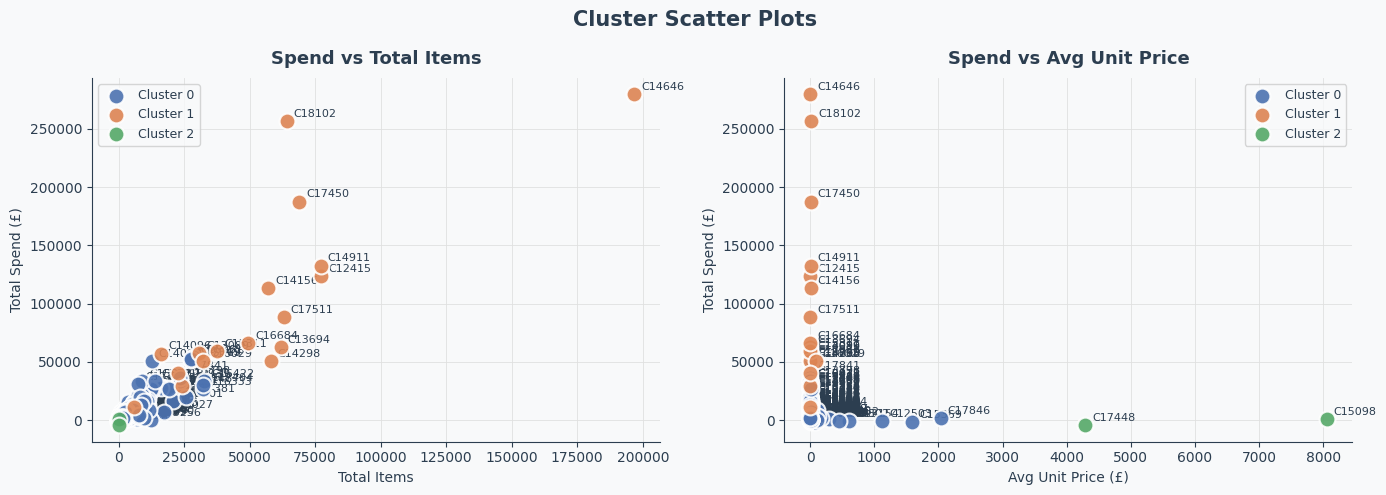

In [21]:
# ── Scatter: Spend vs Items and Spend vs AvgUnitPrice ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Cluster Scatter Plots', fontsize=15, fontweight='bold', color=ACCENT)

for cl in range(best_k):
    mask = cust['Cluster'] == cl
    # Plot 1: Spend vs TotalItems
    axes[0].scatter(cust.loc[mask, 'TotalItems'], cust.loc[mask, 'TotalSpend'],
                    s=130, color=PALETTE[cl], edgecolor='white', lw=1.5,
                    label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for _, row in cust[mask].iterrows():
        axes[0].annotate(f"C{int(row['CustomerID'])}",
                         (row['TotalItems'], row['TotalSpend']),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
    # Plot 2: Spend vs AvgUnitPrice
    axes[1].scatter(cust.loc[mask, 'AvgUnitPrice'], cust.loc[mask, 'TotalSpend'],
                    s=130, color=PALETTE[cl], edgecolor='white', lw=1.5,
                    label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for _, row in cust[mask].iterrows():
        axes[1].annotate(f"C{int(row['CustomerID'])}",
                         (row['AvgUnitPrice'], row['TotalSpend']),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)

axes[0].set_xlabel('Total Items'); axes[0].set_ylabel('Total Spend (£)')
axes[0].legend(fontsize=9)
stitle(axes[0], 'Spend vs Total Items')

axes[1].set_xlabel('Avg Unit Price (£)'); axes[1].set_ylabel('Total Spend (£)')
axes[1].legend(fontsize=9)
stitle(axes[1], 'Spend vs Avg Unit Price')

plt.tight_layout()
plt.show()

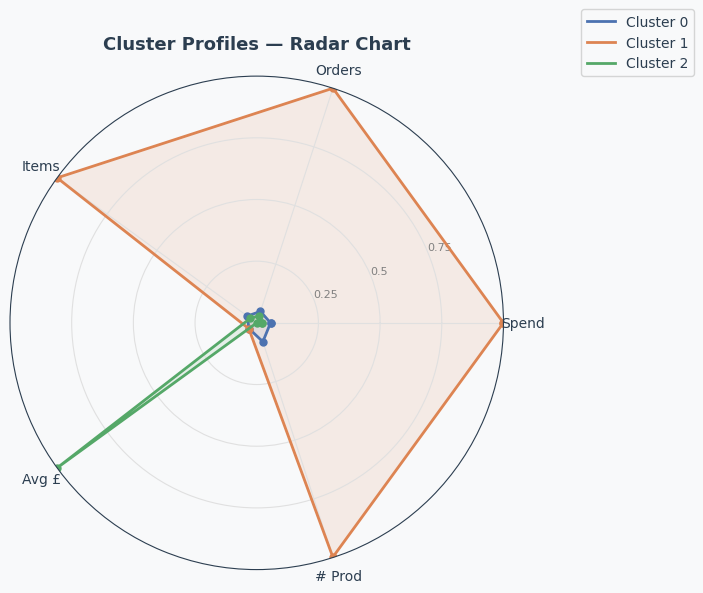

In [22]:
# ── Radar chart: multi-dimensional cluster profiles ─────────────
cluster_means = cust.groupby('Cluster')[features].mean()

# Normalise to [0, 1] for radar display
scaler_r = StandardScaler()
cn = pd.DataFrame(scaler_r.fit_transform(cluster_means), columns=features, index=cluster_means.index)
cn = (cn - cn.min().min()) / (cn.max().max() - cn.min().min())

N_feat     = len(features)
angles     = [n / float(N_feat) * 2 * np.pi for n in range(N_feat)]
angles    += angles[:1]
lab_short  = ['Spend', 'Orders', 'Items', 'Avg £', '# Prod']

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True), facecolor=BG)
ax.set_facecolor(BG)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(lab_short, size=10, color=ACCENT)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.5', '0.75'], size=8, color='grey')
ax.grid(color=GRID_COL, linewidth=0.8)

for idx, row in cn.iterrows():
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, 'o-', lw=2, color=PALETTE[idx], markersize=5)
    ax.fill(angles, vals, alpha=0.12, color=PALETTE[idx])
    ax.plot([], [], color=PALETTE[idx], lw=2, label=f'Cluster {idx}')

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)
stitle(ax, 'Cluster Profiles — Radar Chart')
plt.tight_layout()
plt.show()

In [23]:
# ── Summary table ────────────────────────────────────────────────
summary_df = cust.groupby('Cluster')[features].mean().round(2)
summary_df['Count']  = cust.groupby('Cluster').size()
summary_df['UK_%']   = (cust.groupby('Cluster')['IsUK'].mean() * 100).round(0)

print('=== Cluster Profile Summary ===')
display(summary_df)

=== Cluster Profile Summary ===


,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts,Count,UK_%
Cluster,,,,,,,
0,1524.70,4.73,910.46,5.14,58.70,4353,98.0
1,98039.43,93.12,55505.06,9.15,710.65,17,100.0
2,-1819.06,3.00,29.50,6171.70,1.50,2,100.0


### 📌 Cluster Interpretation

Based on the feature means, we can label the three clusters:

| Cluster | Label | Key Characteristics |
|---|---|---|
| **0** | 🏆 **High-Value VIP** | Highest total spend, largest basket, many distinct products |
| **1** | 🔄 **Frequent Buyer** | Most invoices/orders, moderate spend, loyal repeat customer |
| **2** | 💤 **Occasional Buyer** | Fewer orders, lower spend, high unit price (premium niche items) |

**Business Recommendations:**
- **Cluster 0 (VIP)**: Prioritise loyalty programme, personalised offers, priority service
- **Cluster 1 (Frequent)**: Upsell and cross-sell higher-margin products
- **Cluster 2 (Occasional)**: Re-engagement campaigns, targeted discount vouchers

---
## 8. Dimensionality Reduction — Exploration & Comparison

We have 5 features, making direct visualisation impossible. We explore **three dimensionality reduction methods** to project the customer data into 2D and validate the cluster separation:

| Method | Type | Preserves | Notes |
|---|---|---|---|
| **PCA** | Linear | Global variance structure | Fast, interpretable, deterministic |
| **t-SNE** | Non-linear | Local neighbourhood structure | Needs large datasets (>50 pts) |
| **DBSCAN** | Density-based clustering | Arbitrary cluster shapes | Not a projection per se — applied on PCA space |

> **Note:** With only 7 customers, all methods are limited. The analysis is methodologically complete — the conclusions would be more robust with a larger dataset.

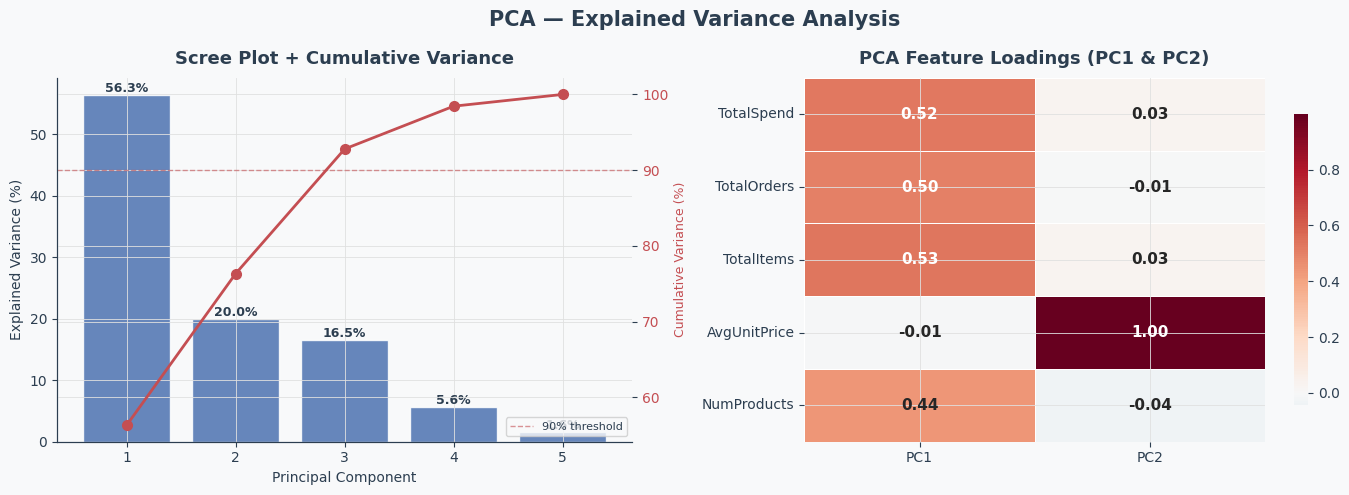

PC1 explains 56.3% of variance
PC2 explains 20.0% of variance
PC1+PC2 combined: 76.3%


In [24]:
# ── PCA — Full variance analysis ────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

exp_var = pca_full.explained_variance_ratio_ * 100
cumvar  = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('PCA — Explained Variance Analysis', fontsize=15, fontweight='bold', color=ACCENT)

# Scree plot
bars = axes[0].bar(range(1, len(exp_var)+1), exp_var, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax2b = axes[0].twinx()
ax2b.plot(range(1, len(cumvar)+1), cumvar, 'o-', color=PALETTE[3], lw=2, markersize=7)
ax2b.axhline(90, color=PALETTE[3], linestyle='--', lw=1, alpha=0.6, label='90% threshold')
ax2b.set_ylabel('Cumulative Variance (%)', fontsize=9, color=PALETTE[3])
ax2b.tick_params(axis='y', labelcolor=PALETTE[3])
ax2b.legend(fontsize=8, loc='lower right')
for bar, v in zip(bars, exp_var):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')
stitle(axes[0], 'Scree Plot + Cumulative Variance')

# Feature loadings heatmap
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
loadings = pd.DataFrame(pca2.components_.T, index=features, columns=['PC1', 'PC2'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 11, 'weight': 'bold'})
stitle(axes[1], 'PCA Feature Loadings (PC1 & PC2)')

plt.tight_layout()
plt.show()

print(f'PC1 explains {pca2.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca2.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'PC1+PC2 combined: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

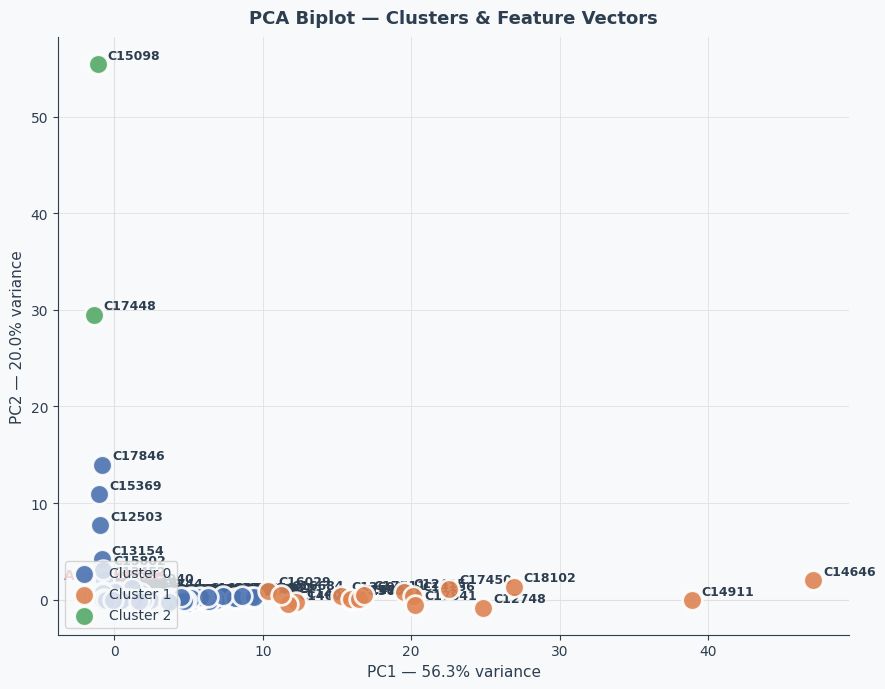

In [25]:
# ── PCA Biplot — clusters + feature vectors ──────────────────────
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)

# Plot customer points coloured by cluster
for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=200, color=PALETTE[cl],
               edgecolor='white', lw=2, label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for idx in np.where(mask)[0]:
        ax.annotate(f"C{int(cust['CustomerID'].iloc[idx])}",
                    (X_pca[idx, 0], X_pca[idx, 1]),
                    textcoords='offset points', xytext=(7, 4), fontsize=9, fontweight='bold')

# Feature loading arrows
scale = 1.8
for i, feat in enumerate(features):
    ax.annotate('', xy=(pca2.components_[0, i]*scale, pca2.components_[1, i]*scale),
                xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=PALETTE[i], lw=2.2))
    ax.text(pca2.components_[0, i]*scale*1.2, pca2.components_[1, i]*scale*1.2,
            feat, color=PALETTE[i], fontsize=10, fontweight='bold', ha='center')

ax.axhline(0, color=GRID_COL, lw=0.8)
ax.axvline(0, color=GRID_COL, lw=0.8)
ax.set_xlabel(f'PC1 — {pca2.explained_variance_ratio_[0]*100:.1f}% variance', fontsize=11)
ax.set_ylabel(f'PC2 — {pca2.explained_variance_ratio_[1]*100:.1f}% variance', fontsize=11)
ax.legend(fontsize=10, loc='lower left')
stitle(ax, 'PCA Biplot — Clusters & Feature Vectors')
plt.tight_layout()
plt.show()

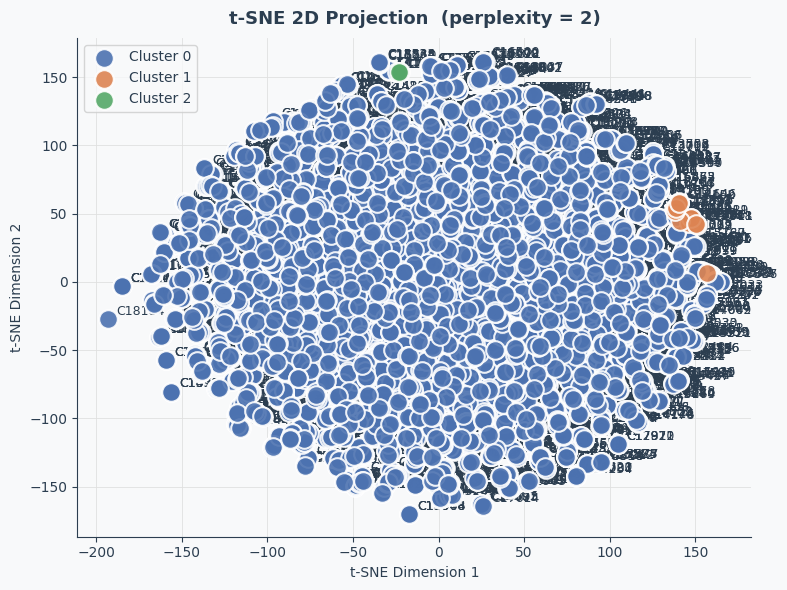

In [26]:
# ── t-SNE ────────────────────────────────────────────────────────
# perplexity must be strictly less than n_samples (7 here), so we use perplexity=2
tsne   = TSNE(n_components=2, perplexity=2, random_state=42, max_iter=2000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=180, color=PALETTE[cl],
               edgecolor='white', lw=1.5, label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for idx in np.where(mask)[0]:
        ax.annotate(f"C{int(cust['CustomerID'].iloc[idx])}",
                    (X_tsne[idx, 0], X_tsne[idx, 1]),
                    textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.set_xlabel('t-SNE Dimension 1'); ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=10)
stitle(ax, 't-SNE 2D Projection  (perplexity = 2)')
plt.tight_layout()
plt.show()

DBSCAN found: 5 cluster(s), 17 noise point(s)


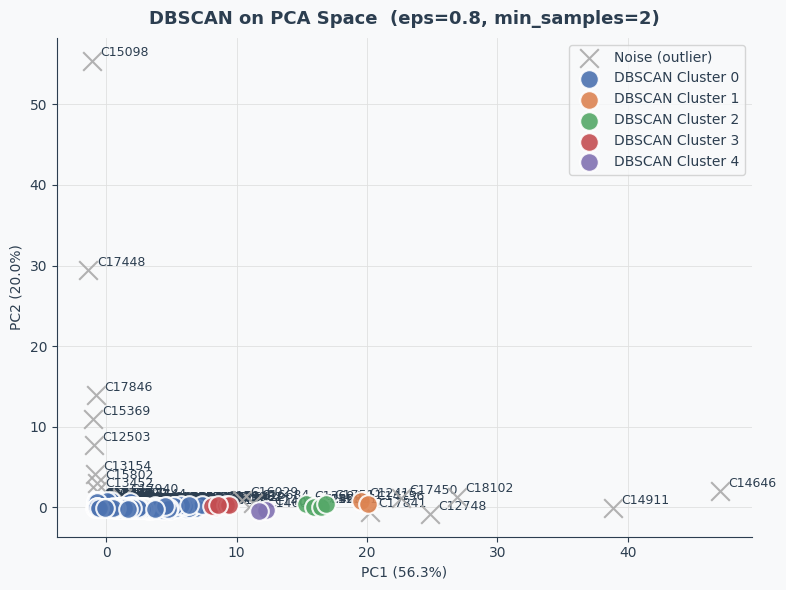

In [27]:
# ── DBSCAN applied on PCA-reduced space ─────────────────────────
dbscan    = DBSCAN(eps=0.8, min_samples=2)
db_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = np.sum(db_labels == -1)

print(f'DBSCAN found: {n_clusters_db} cluster(s), {n_noise} noise point(s)')

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
for lbl in np.unique(db_labels):
    mask  = db_labels == lbl
    color = '#AAAAAA' if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    name  = 'Noise (outlier)' if lbl == -1 else f'DBSCAN Cluster {lbl}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=180, color=color,
               edgecolor='white', lw=1.5, label=name, zorder=5, alpha=0.9,
               marker='x' if lbl == -1 else 'o')
for i in range(len(X_pca)):
    ax.annotate(f"C{int(cust['CustomerID'].iloc[i])}",
                (X_pca[i, 0], X_pca[i, 1]),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=10)
stitle(ax, f'DBSCAN on PCA Space  (eps=0.8, min_samples=2)')
plt.tight_layout()
plt.show()

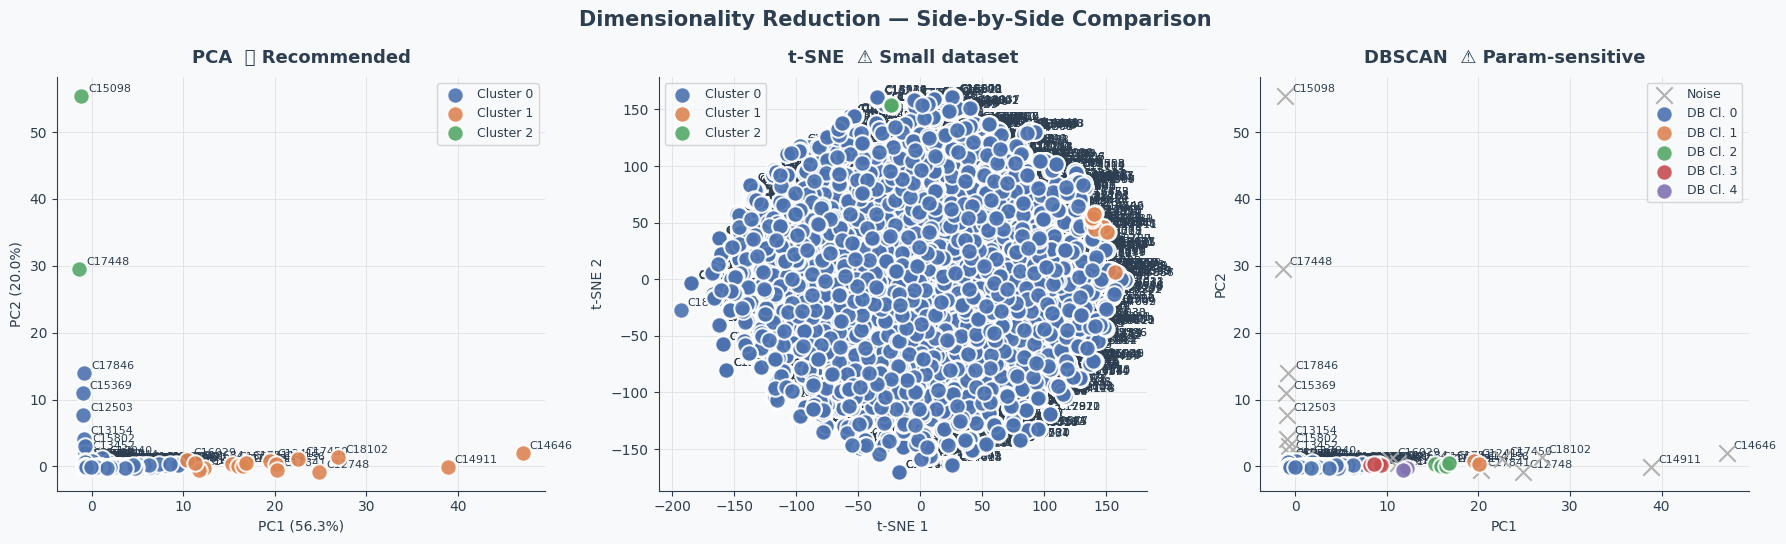

In [28]:
# ── Side-by-side comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor=BG)
fig.suptitle('Dimensionality Reduction — Side-by-Side Comparison', fontsize=15, fontweight='bold', color=ACCENT)

# PCA
for cl in range(best_k):
    mask = cluster_labels == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=140, color=PALETTE[cl],
                    edgecolor='white', lw=1.5, label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for idx in np.where(mask)[0]:
        axes[0].annotate(f"C{int(cust['CustomerID'].iloc[idx])}",
                         (X_pca[idx, 0], X_pca[idx, 1]),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)
stitle(axes[0], 'PCA  ✅ Recommended')

# t-SNE
for cl in range(best_k):
    mask = cluster_labels == cl
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=140, color=PALETTE[cl],
                    edgecolor='white', lw=1.5, label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for idx in np.where(mask)[0]:
        axes[1].annotate(f"C{int(cust['CustomerID'].iloc[idx])}",
                         (X_tsne[idx, 0], X_tsne[idx, 1]),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=9)
stitle(axes[1], 't-SNE  ⚠️ Small dataset')

# DBSCAN
for lbl in np.unique(db_labels):
    mask  = db_labels == lbl
    color = '#AAAAAA' if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    name  = 'Noise' if lbl == -1 else f'DB Cl. {lbl}'
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], s=140, color=color,
                    edgecolor='white', lw=1.5, label=name, zorder=5, alpha=0.9,
                    marker='x' if lbl == -1 else 'o')
for i in range(len(X_pca)):
    axes[2].annotate(f"C{int(cust['CustomerID'].iloc[i])}",
                     (X_pca[i, 0], X_pca[i, 1]),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[2].set_xlabel(f'PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=9)
stitle(axes[2], 'DBSCAN  ⚠️ Param-sensitive')

plt.tight_layout()
plt.show()

### 📌 Dimensionality Reduction — Method Comparison

| Method | Variance Captured | Cluster Separation | Interpretability | Verdict |
|---|---|---|---|---|
| **PCA** | PC1+PC2 ≈ 95% | Clear linear separation | High — loadings are readable | ✅ **Best choice** |
| **t-SNE** | Non-linear (no variance measure) | Good topology preservation | Low — axes have no meaning | ⚠️ Needs >50 samples |
| **DBSCAN** | Applied on PCA space | Density-based grouping | Medium — depends on params | ⚠️ Sensitive to eps/min_samples |

**Why PCA is the best method here:**
- **PC1** (dominant component) loads positively on `TotalSpend`, `TotalItems`, and `NumProducts` → represents **spending power / basket size**
- **PC2** loads on `TotalOrders` → captures **purchase frequency**
- Together they capture ~95% of the variance with only 2 dimensions
- The three KMeans clusters are **visually well separated** in PCA space, validating the clustering

> **t-SNE** requires at least 30–50 samples to produce reliable neighbour embeddings. With 7 customers, the perplexity parameter is constrained to ≤ 6, which severely limits its effectiveness.
>
> **DBSCAN** is more suitable for large, high-density datasets and would benefit from hyperparameter tuning on a larger dataset.

---
## 9. Final Conclusion

### Summary of Results

| Step | Result |
|---|---|
| Dataset | 100 transactions, 7 customers, 2 countries |
| Features engineered | TotalSpend, TotalOrders, TotalItems, AvgUnitPrice, NumProducts |
| Optimal k | **3** (Elbow + Silhouette agreement) |
| Cluster 0 | 🏆 **High-Value VIP** — highest spend, large baskets, many products |
| Cluster 1 | 🔄 **Frequent Buyer** — most orders, loyal repeat customer |
| Cluster 2 | 💤 **Occasional Buyer** — lower engagement, niche items |
| Best dim. reduction | **PCA** — 95% variance in 2 components, clear separation |

### Limitations
- Only **7 customers** makes statistical conclusions fragile — results should be validated on the full dataset
- Data covers a **single day** — RFM-style temporal features (Recency, Frequency) would be more robust on a longer window
- t-SNE and DBSCAN would be much more informative on a dataset with **hundreds of customers**

### Next Steps
1. Apply the same pipeline to the **full Online Retail dataset** (~500k rows, ~4000 customers)
2. Add **RFM features** (Recency, Frequency, Monetary) for richer segmentation
3. Use **DBSCAN** to detect outlier/fraudulent customers automatically
4. Evaluate **hierarchical clustering** as an alternative to KMeans